## analysing some miscallaneous changes post net zero using ACCESS net zero runs – such as SH sea ice extent and changes in poleward heat transport

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [5]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [6]:
import cmocean
from scipy import stats

In [7]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [8]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [9]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [76]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax



def add_qk_bbox(ax, qk, q, patch_zorder):
    # --- Add a box around both arrow and label ---
    # Choose size & position in Axes fraction coordinates
    box_x, box_y = 1.03, 1.07   # lower-left corner of box
    box_w, box_h = 0.14, 0.05    # width & height of box

    rect = mpatches.FancyBboxPatch(
        (box_x, box_y), box_w, box_h,
        transform=ax.transAxes,
        boxstyle="square,pad=0.25",
        facecolor='white', edgecolor='black', alpha=1.0,
        zorder=patch_zorder, clip_on=True  # below text & arrow
    )
    ax.add_patch(rect)

    # Raise the quiverkey elements above the box
    qk.text.set_zorder(4)
    q.set_zorder(2)


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            # step = max(1, x.shape[0] // 2)
            step = 6
            # q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale_units='xy', scale=wind_scale, width=0.003, headwidth=3, headlength=4, headaxislength=3, color='k', pivot='middle', transform=ccrs.PlateCarree())
            if i == 0:
                qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
                add_qk_bbox(axlist[i], qk, q, patch_zorder=4)
            # qk.text.set_bbox(dict(facecolor='white', edgecolor='k', boxstyle='square,pad=0.3'))

        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 6
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        # qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))

        plt.tight_layout()
        plt.show()
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return ax

In [11]:
from functions import preproc_funcs as funcs

In [12]:
from functions import xr_lowess

### import data

In [13]:
siext_sh_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_siextents_original.nc').siextents.load()
siext_sh_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_siextents.nc').siextents.load()

In [14]:
siext_nh_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_siextentn_original.nc').siextentn.load()
siext_nh_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_siextentn.nc').siextentn.load()

In [15]:
def fix_da(da):
    da_detrend = funcs.detrend_rolling_window(da, window_size=50)
    return da.where(da_detrend < 100*da_detrend.std('time'))

Text(0, 0.5, 'Sea ice extent ($\\times$ 10$^{6}$ km$^{2}$)')

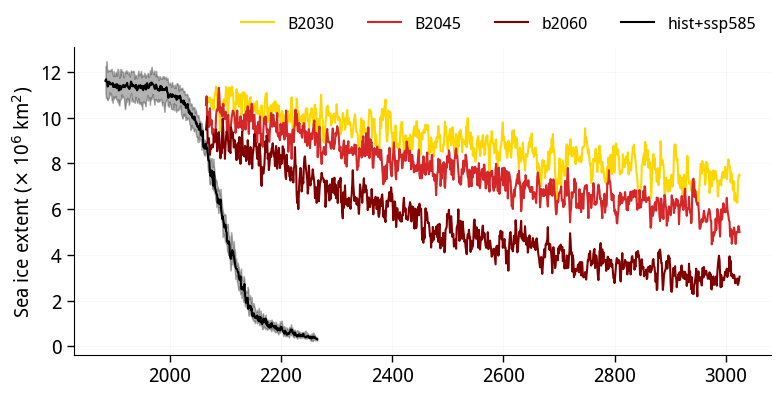

In [16]:
plt.figure(figsize=(9,4))

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2030').quantile(0.5, dim='time'), color='gold')

# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2035'), color='tab:orange', lw=1.5, label='B2035', alpha=0.2)
# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2040'), color='tomato', lw=1.5, label='B2040', alpha=0.2)

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2050'), color='darkred', lw=1.5, label='B2050', alpha=0.2)
# plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2055'), color='tab:brown', lw=1.5, label='B2055', alpha=0.2)

plt.plot(siext_sh_stable_orig.isel(time = slice(35, -35)).time.dt.year, siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model = '2060'), color='maroon', lw=1.5, label='b2060')
# plt.axhline(siext_sh_stable_orig.isel(time = slice(35, -35)).sel(model='B2060').quantile(0.5, dim='time'), color='maroon')




plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.1, 'model'), fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.1, 'model'), conc_fix_da(fix_da(siext_sh_trans_orig)).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=5, bbox_to_anchor=(1., 1.))
plot_decorator()
plt.ylabel(r'Sea ice extent ($\times$ 10$^{6}$ km$^{2}$)')
# plt.xlabel('Year')


Text(0, 0.5, 'Sea ice extent ($\\times$ 10$^{6}$ km$^{2}$)')

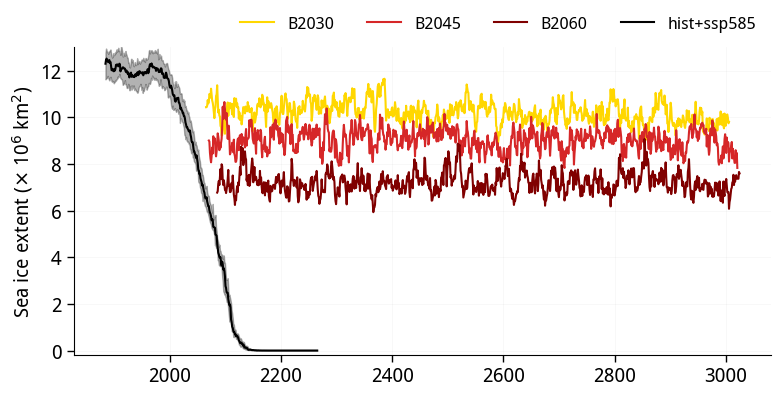

In [17]:
plt.figure(figsize=(9,4))

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model = '2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(fix_da(siext_nh_stable_orig).isel(time = slice(35, -35)).sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.1, 'model'), fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).time.dt.year, conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.1, 'model'), conc_fix_da(siext_nh_trans_orig).isel(time = slice(35, -35)).quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=5, bbox_to_anchor=(1., 1.))
plot_decorator()
plt.ylim(-.2, 13)
plt.ylabel(r'Sea ice extent ($\times$ 10$^{6}$ km$^{2}$)')
# plt.xlabel('Year')


### Barotropic streamfunction changes

In [18]:
msftbarot_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_msftbarot_original.nc').msftbarot.load()
msftbarot_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_msftbarot.nc').msftbarot.load()

In [49]:
msftbarot_trans = funcs.calc_anom(msftbarot_trans_orig, msftbarot_trans_orig.sel(model = 'ACCESS-ESM1-5_r10i1p1f', time = slice('1960', '1990')))
msftbarot_stable = funcs.calc_anom_annual(msftbarot_stable_orig, msftbarot_trans_orig.sel(model = 'ACCESS-ESM1-5_r10i1p1f', time = slice('1960', '1990')))

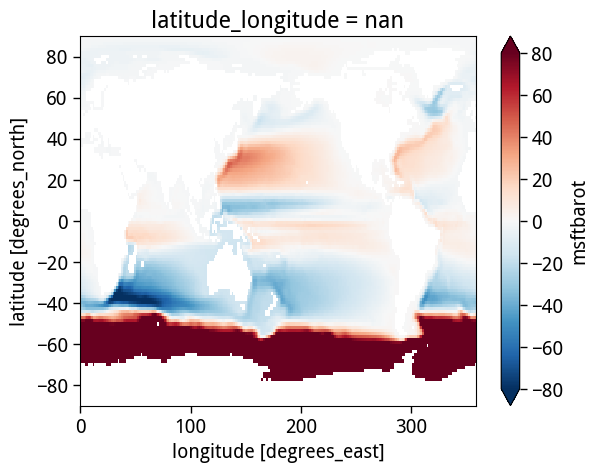

In [24]:
(msftbarot_trans_orig.sel(time = slice('1850', '1900')).mean(('model', 'time'))/1e9).plot(vmin = -80)

In [29]:
# plot_list = [
#     (msftbarot_trans.msftbarot/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (msftbarot_trans.msftbarot/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (msftbarot_trans.msftbarot/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (msftbarot_trans).sel(lat = slice(-90, 90)).sel(time = slice('2045', '2075')).mean(('model', 'time'))/1e9,
    (msftbarot_trans).sel(lat = slice(-90, 90)).sel(time = slice('2030', '2060')).mean(('model', 'time'))/1e9,
    (msftbarot_trans).sel(lat = slice(-90, 90)).sel(time = slice('2015', '2045')).mean(('model', 'time'))/1e9,
]

In [30]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [31]:
contour_data = [
    (msftbarot_trans_orig).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time'))/1e9,
    (msftbarot_trans_orig).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time'))/1e9,
    (msftbarot_trans_orig).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time'))/1e9,
]

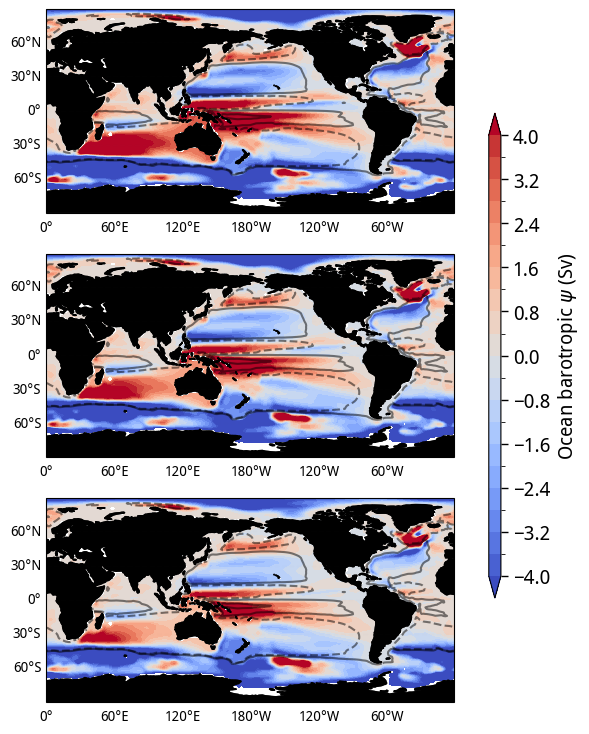

In [41]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap='coolwarm', levels = np.linspace(-4, 4, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-5, 5], contour_colors='k', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Ocean barotropic $\psi$ (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [42]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [50]:
stable_plot_list = [
    additional_sampling_stabilisation((msftbarot_stable).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060'))).mean(('model'))/1e9,
    additional_sampling_stabilisation((msftbarot_stable).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045'))).mean(('model'))/1e9,
    additional_sampling_stabilisation((msftbarot_stable).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030'))).mean(('model'))/1e9,
]

Done
Done
Done


In [51]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [52]:
pval_list = [
    funcs.mannwhitneyu3d((msftbarot_trans).sel(lat = slice(-90, 90), time = slice('2045', '2075')).mean(('time'))/1e9, additional_sampling_stabilisation((msftbarot_stable).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060')))/1e9, dim='model'),
    funcs.mannwhitneyu3d((msftbarot_trans).sel(lat = slice(-90, 90), time = slice('2030', '2060')).mean(('time'))/1e9, additional_sampling_stabilisation((msftbarot_stable).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045')))/1e9, dim='model'),
    funcs.mannwhitneyu3d((msftbarot_trans).sel(lat = slice(-90, 90), time = slice('2015', '2045')).mean(('time'))/1e9, additional_sampling_stabilisation((msftbarot_stable).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030')))/1e9, dim='model'),
]

Done
Done
Done


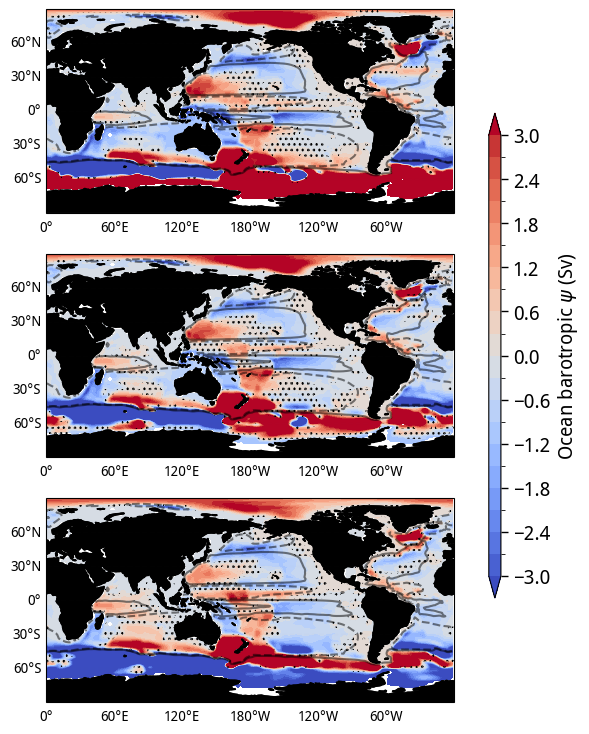

In [54]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap='coolwarm', levels = np.linspace(-3, 3, 21), pval = pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-5, 5], contour_colors='k', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Ocean barotropic $\psi$ (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


### Upwelling changes

In [55]:
import glob

In [56]:
def open_da_zarr(files):
    datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
    combined = xr.concat([ds['wo'] for ds in datasets], dim='model')
    return combined.load()

In [57]:
from dask.diagnostics import ProgressBar

In [58]:
files_trans = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/wo/*.zarr')
with ProgressBar():
    wo_trans_orig = open_da_zarr(files_trans)

[########################################] | 100% Completed | 203.55 ms
[########################################] | 100% Completed | 203.59 ms
[########################################] | 100% Completed | 102.25 ms
[########################################] | 100% Completed | 102.18 ms
[########################################] | 100% Completed | 102.33 ms
[########################################] | 100% Completed | 102.48 ms
[########################################] | 100% Completed | 203.52 ms
[########################################] | 100% Completed | 202.72 ms
[########################################] | 100% Completed | 304.61 ms
[########################################] | 100% Completed | 203.98 ms
[########################################] | 100% Completed | 102.52 ms
[########################################] | 100% Completed | 202.83 ms
[########################################] | 100% Completed | 203.43 ms
[########################################] | 100% Completed | 10

In [59]:
# thetao_tropics_trans = funcs.calc_anom(thetao_tropics_trans_orig, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990')))

In [60]:
with ProgressBar():
    wo_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2030*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')
    wo_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2045*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')
    wo_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2060*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')


[########################################] | 100% Completed | 12.56 ss
done
[########################################] | 100% Completed | 10.64 s
done
[########################################] | 100% Completed | 9.73 sms
done


In [61]:
import xesmf as xe

In [62]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [63]:
regridder = xe.Regridder(wo_trans_orig, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [64]:
wo_trans_orig = regridder(wo_trans_orig)
wo_stable2030 = regridder(wo_stable2030)
wo_stable2045 = regridder(wo_stable2045)
wo_stable2060 = regridder(wo_stable2060)

In [65]:
wo_trans_orig

<xarray.DataArray (model: 40, time: 252, lat: 120, lon: 240)> Size: 1GB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 9.64644045e-08,  8.03598539e-08,  6.52638406e-08, ...,
           1.55913057e-07,  1.34740986e-07,  1.13165036e-07],
         [-1.11565676e-07, -1.12963733e-07, -1.13808277e-07, ...,
          -1.06218948e-07, -1.07981649e-07, -1.09737393e-07],
         [ 4.32721947e-08,  4.18990211e-08,  4.06094713e-08, ...,
           4.56335520e-08,  4.50987159e-08,  4.47296706e-08]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
           3.60310537e-07,  3.69633000e-07,  3.77295947e-07],
         [ 9.37159683e-08,  8.22055100e-08,  7.06890333e-08, ...,
           1.06223311e-07,  1.05456841e-07,  1.04775538e-07],
         [-4.38616581e-07, -4.48067595e-07, -4.57775599e-07, ...,
          -4.26291962e-07, -4.27831111e-07, -4.29414030e-07]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 1.01208730e-06,  1.02216018e-06,  1.01359456e-06, ...,
           1.02936372e-06,  1.01577484e-06,  1.00266118e-06],
         [ 7.34932087e-07,  7.31781824e-07,  7.29607791e-07, ...,
           7.26404721e-07,  7.32204001e-07,  7.38553524e-07],
         [ 6.04587058e-07,  6.00856652e-07,  5.97314056e-07, ...,
           6.01088118e-07,  6.04649472e-07,  6.08481571e-07]]]],
      dtype=float32)
Coordinates:
  * time                (time) object 2kB 1849-06-01 00:00:00 ... 2100-06-01 ...
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
Dimensions without coordinates: model
Attributes:
    regrid_method:  bilinear

In [66]:
wo_trans = funcs.calc_anom(wo_trans_orig, wo_trans_orig.sel(model = 10, time = slice('1960', '1990')))

In [67]:
wo_stable2030_anom = funcs.calc_anom_annual(wo_stable2030, wo_trans_orig.sel(model = 10, time = slice('1960', '1990')))
wo_stable2045_anom = funcs.calc_anom_annual(wo_stable2045, wo_trans_orig.sel(model = 10, time = slice('1960', '1990')))
wo_stable2060_anom = funcs.calc_anom_annual(wo_stable2060, wo_trans_orig.sel(model = 10, time = slice('1960', '1990')))

In [68]:
# plot_list = [
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [69]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [70]:
contour_data = [
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
]

In [71]:
contour_data[0]

<xarray.DataArray (lat: 40, lon: 240)> Size: 38kB
array([[  6.192501 ,  10.179307 ,   2.6421902, ...,  -9.693975 ,
        -10.980364 ,  -3.3894987],
       [-17.29162  ,  -5.243339 ,  -8.972873 , ..., -12.096696 ,
        -10.148461 ,  30.965828 ],
       [-30.464268 ,  -9.537198 , -11.108943 , ..., -14.648148 ,
        -21.74561  , -25.00525  ],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], dtype=float32)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 320B -44.25 -42.75 -41.25 ... 12.75 14.25

In [78]:
basin_mask = xc.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Ofx/basin/gn/latest/basin_Ofx_ACCESS-ESM1-5_historical_r10i1p1f1_gn.nc')
basin_mask

2025-10-16 21:26:00,718 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-10-16 21:26:00,718 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-10-16 21:26:00,733 [WARNING]: bounds.py(add_missing_bounds:191) >> The j coord variable has a 'units' attribute that is not in degrees.
2025-10-16 21:26:00,733 [WARNING]: bounds.py(add_missing_bounds

<xarray.Dataset> Size: 10MB
Dimensions:             (j: 300, i: 360, vertices: 4, bnds: 2)
Coordinates:
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB -77.88 -77.88 ... 65.63 65.21
    longitude           (j, i) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
Dimensions without coordinates: vertices, bnds
Data variables:
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    basin               (j, i) float64 864kB ...
    i_bnds              (i, bnds) float64 6kB -0.5 0.5 0.5 ... 358.5 358.5 359.5
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T04:50:43Z
    ...                     ...
    tracking_id:            hdl:21.14100/13699ec4-baf3-415d-a4c7-8b6d820b233d
    variable_id:            basin
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0

In [79]:
regridder = xe.Regridder(basin_mask, ds_out, 'nearest_s2d', periodic=True, ignore_degenerate=True)

In [80]:
basin_mask_regrid = regridder(basin_mask).basin

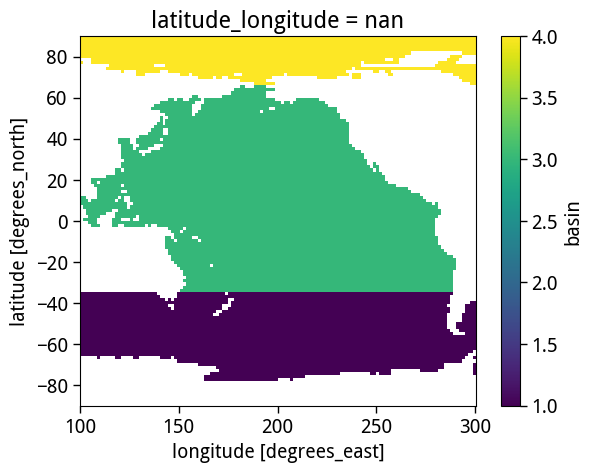

In [113]:
basin_mask_indo_pacific_so_pacific = basin_mask_regrid.where(basin_mask_regrid.isin([1,3,4]))
basin_mask_indo_pacific = basin_mask_regrid.where(basin_mask_regrid.isin([3]))
basin_mask_indo_pacific_so_pacific.sel(lon = slice(100, 300)).plot()

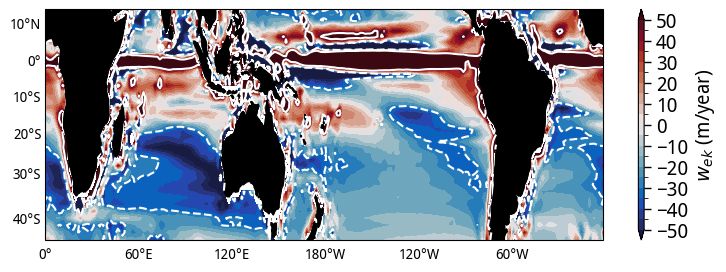

In [77]:
zz = (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time'))

ax = plot_single_map(xx, yy, zz, '', '', cmap=cmocean.cm.balance, levels=np.linspace(-50, 50, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(9,3), land_mask_list = True, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Mercator(central_longitude=180),
                cbar_kwargs=dict(orientation='vertical', label='$w_{ek}$ (m/year)', aspect=40, shrink=1.0, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)
ax.contour(xx, yy, zz, levels=[-30, 50], colors='white', transform=ccrs.PlateCarree())

In [ ]:
test = gaussian_filter_ocean(wo_trans_orig*3.154e7).where(basin_mask_indo_pacific_so_pacific.isin([1, 3, 4]).sel(lon = slice(100, 300))).mean('lon')

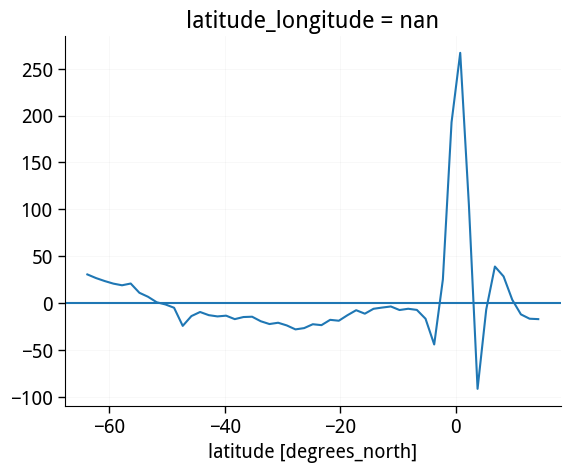

In [149]:
test.sel(time = slice('1850', '1900')).mean(('model', 'time')).plot()
plt.axhline(0)
plot_decorator()

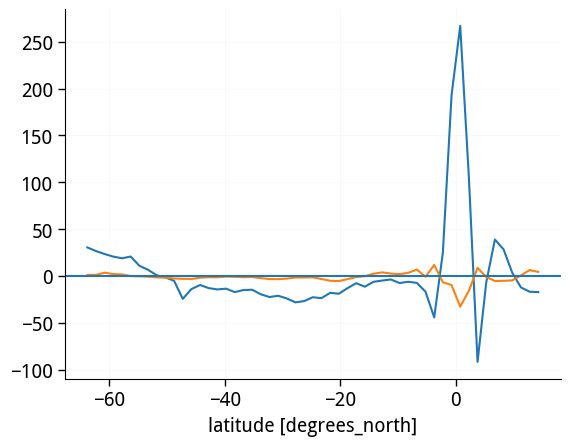

In [150]:
test1 = (wo_trans*3.154e7).where(basin_mask_indo_pacific_so_pacific.isin([1, 3, 4]).sel(lon = slice(160, 270), lat = slice(-65, 15))).mean('lon')
test.sel(time = slice('1850', '1900')).mean(('model', 'time')).plot()
test1.sel(time = slice('2045', '2075')).mean(('model', 'time')).plot()
plt.axhline(0)
plot_decorator()

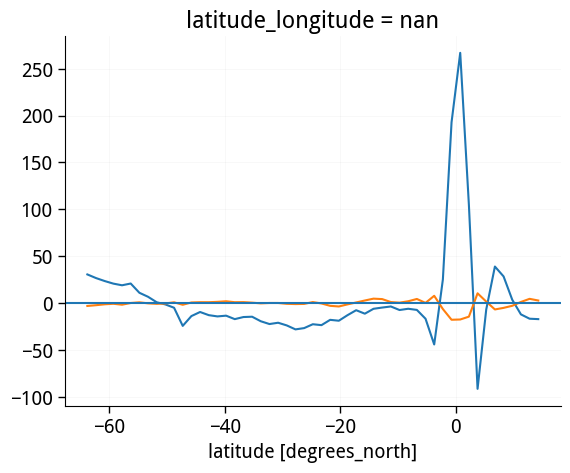

In [151]:
test2 = (wo_stable2060_anom*3.154e7).where(basin_mask_indo_pacific_so_pacific.isin([1, 3, 4]).sel(lon = slice(160, 270), lat = slice(-65, 15))).mean('lon')
test.sel(time = slice('1850', '1900')).mean(('model', 'time')).plot()
(test2.wo.mean('time') - test1.mean(('model', 'time'))).plot()
# (test2.wo.mean('time')).plot()
plt.axhline(0)
plot_decorator()

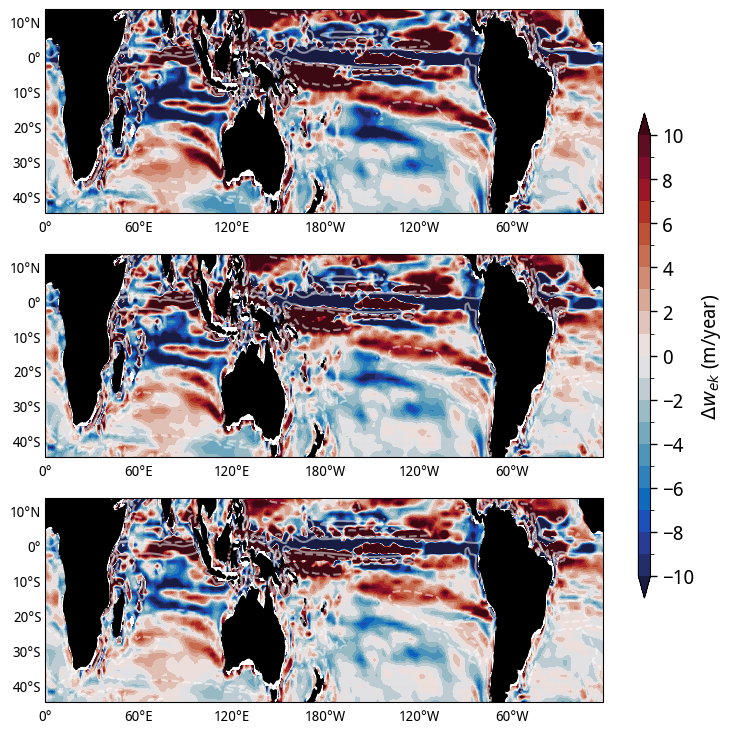

In [147]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-10, 10, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-30, 50], contour_colors='white', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='$\Delta w_{ek}$ (m/year)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)


In [ ]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [175]:
stable_plot_list = [
    additional_sampling_stabilisation((wo_stable2060_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((wo_stable2045_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((wo_stable2030_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


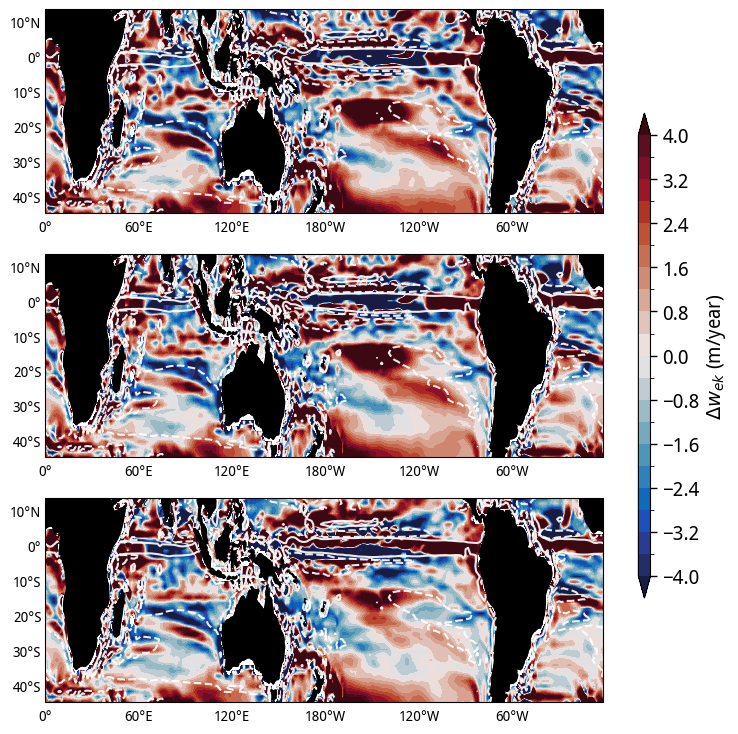

In [ ]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-4, 4, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-30, 50], contour_colors='white', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='$\Delta w_{ek}$ (m/year)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)


In [153]:
from scipy.ndimage import gaussian_filter

In [188]:
def gaussian_filter_ocean(da, sigma=1.5):
    """
    Apply Gaussian smoothing over ocean only, ignoring NaNs (land).
    """
    data = da.copy()
    data_values = data.fillna(0)
    mask = np.isfinite(data)
    # apply Gaussian filter to both data and mask
    smooth_data = gaussian_filter(data_values, sigma=sigma)
    smooth_mask = gaussian_filter(mask.astype(float), sigma=sigma)
    # re-normalize so NaNs don't bleed into ocean
    result = smooth_data / smooth_mask
    result[~mask] = np.nan
    return xr.DataArray(result, coords=data.coords, dims=data.dims, name=data.name)

# Example usage:
# w_change_smooth = gaussian_filter_ocean(w_change, sigma=2)

In [189]:
test = gaussian_filter_ocean(plot_list[0])

In [190]:
test1 = gaussian_filter_ocean(stable_plot_list[0])

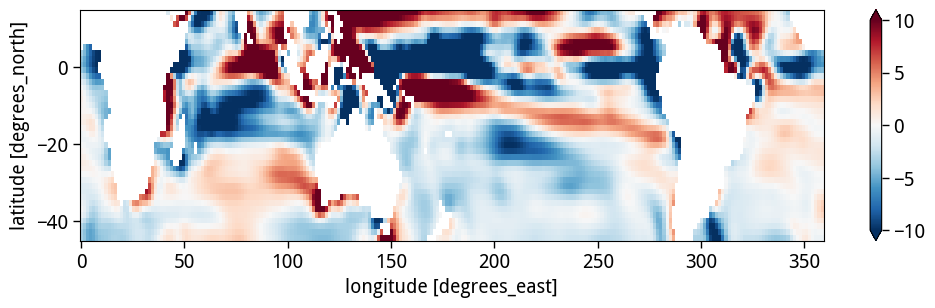

In [191]:
plt.figure(figsize=(12,3))
test.plot(vmin=-10)

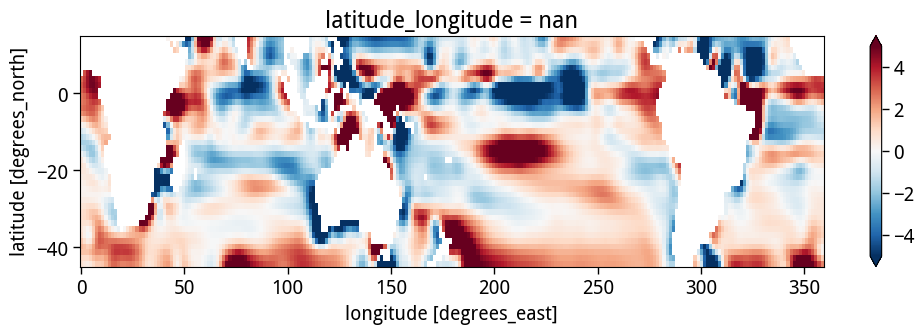

In [192]:
plt.figure(figsize=(12,3))
(test1 - test).plot(vmin=-5)